In [4]:

# WhatsApp Chat Analysis


# 1. Install required libraries
!pip install pandas matplotlib wordcloud emoji

# 2. Import libraries
import pandas as pd
import re
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import emoji

# 3. Upload WhatsApp chat file (.txt)
from google.colab import files
uploaded = files.upload()
chat_file = list(uploaded.keys())[0]

# 4. Read chat file
with open(chat_file, encoding='utf-8') as f:
    data = f.read().split('\n')

# 5. UNIVERSAL WhatsApp parser (ALL formats supported)
dates, times, users, messages = [], [], [], []

pattern = re.compile(
    r'^\[?(\d{1,2}[\/\-]\d{1,2}[\/\-]\d{2,4}),?\s'
    r'(\d{1,2}:\d{2}(?::\d{2})?\s?(?:AM|PM|am|pm)?)\]?\s[-–]\s'
    r'([^:]+):\s(.*)'
)

for line in data:
    match = pattern.match(line)
    if match:
        dates.append(match.group(1))
        times.append(match.group(2))
        users.append(match.group(3))
        messages.append(match.group(4))
    else:
        # Handle multiline messages
        if messages:
            messages[-1] += " " + line

# 6. Create DataFrame
df = pd.DataFrame({
    "date": dates,
    "time": times,
    "user": users,
    "message": messages
})

print("Total Messages:", len(df))
print("Unique Users:", df['user'].nunique())
df.head()


Saving WhatsApp Chat with Sehaj VIT.txt to WhatsApp Chat with Sehaj VIT (3).txt
Total Messages: 3814
Unique Users: 2


,date,time,user,message
0,8/22/23,10:36 AM,Aditya Sinha,Bhai humtoh abhi college pahunche hain
1,8/22/23,10:36 AM,Aditya Sinha,Class mein kya hua Aaj?
2,8/22/23,10:37 AM,Sehaj VIT,Orientation chalu hai
3,8/22/23,10:37 AM,Sehaj VIT,Auditorium mai
4,8/22/23,10:37 AM,Aditya Sinha,Aajayein kya abhi?


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128077 (\N{THUMBS UP SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128128 (\N{SKULL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127995 (\N{EMOJI MODIFIER FITZPATRICK TYPE-1-2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


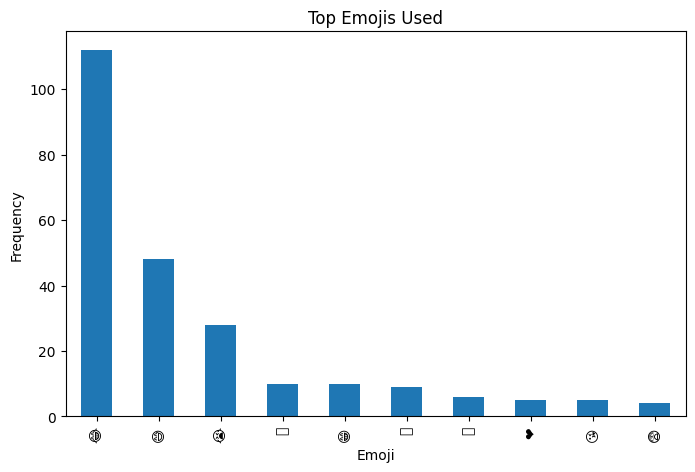

In [5]:
def extract_emojis(text):
    return [c for c in text if c in emoji.EMOJI_DATA]

df['emojis'] = df['message'].apply(extract_emojis)

emoji_list = sum(df['emojis'], [])
emoji_freq = pd.Series(emoji_list).value_counts().head(10)

if not emoji_freq.empty:
    plt.figure(figsize=(8,5))
    emoji_freq.plot(kind='bar')
    plt.title("Top Emojis Used")
    plt.xlabel("Emoji")
    plt.ylabel("Frequency")
    plt.show()
else:
    print("No emojis found.")


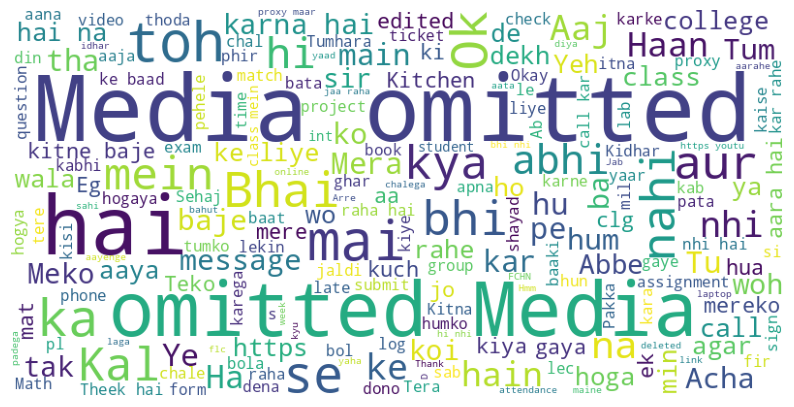

In [6]:
all_words = ' '.join(df['message'])

if len(all_words.strip()) > 0:
    wc = WordCloud(width=800, height=400, background_color='white').generate(all_words)
    plt.figure(figsize=(10,6))
    plt.imshow(wc)
    plt.axis('off')
    plt.show()
else:
    print("No text available for Word Cloud.")
